🔄 Loading dataset...
Initial dataset: 23,078 rows

🔄 Converting to binary classification...
Class distribution:
Level_binary
1    0.521016
0    0.478984
Name: proportion, dtype: float64

🔄 Removing nulls and duplicates...
After cleaning: 23,078 rows
Train shape: (18462, 2) | Test shape: (4616, 2)

🔍 Running RandomizedSearchCV...
Fitting 5 folds for each of 25 candidates, totalling 125 fits

✅ Best Parameters:
{'dt__min_samples_split': 2, 'dt__min_samples_leaf': 4, 'dt__max_depth': 5, 'dt__criterion': 'gini', 'dt__class_weight': 'balanced'}

📊 Classification Report (Binary):
                precision    recall  f1-score   support

No Interaction       0.93      0.92      0.93      2211
   Interaction       0.93      0.94      0.93      2405

      accuracy                           0.93      4616
     macro avg       0.93      0.93      0.93      4616
  weighted avg       0.93      0.93      0.93      4616



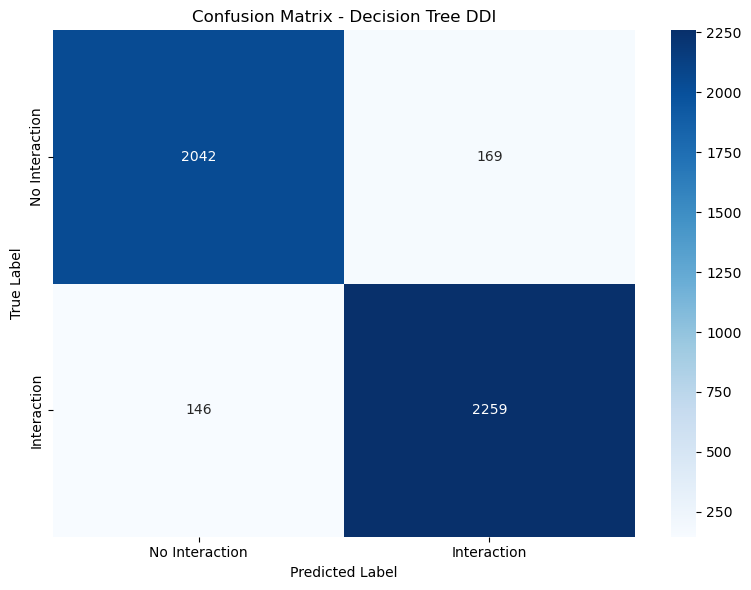

In [1]:
import pandas as pd
import numpy as np
import warnings
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import TargetEncoder, StandardScaler
from sklearn.pipeline import Pipeline
import seaborn as sns
import matplotlib.pyplot as plt
import joblib

warnings.filterwarnings('ignore')

# ====================== STEP 1: LOAD DATA ======================
print("🔄 Loading dataset...")

df = pd.read_csv('DDinter_with_negatives.csv')

# Normalize drug names
df['Drug_A'] = df['Drug_A'].str.lower().str.strip()
df['Drug_B'] = df['Drug_B'].str.lower().str.strip()

print(f"Initial dataset: {len(df):,} rows")

# ====================== STEP 2: CREATE BINARY TARGET ======================
print("\n🔄 Converting to binary classification...")

df['Level_binary'] = df['Level'].apply(
    lambda x: 0 if str(x).strip().lower() in ['none', 'no interaction', '0'] else 1
)

print("Class distribution:")
print(df['Level_binary'].value_counts(normalize=True))

# ====================== STEP 3: INITIAL CLEANING ======================
print("\n🔄 Removing nulls and duplicates...")
df = df.dropna(subset=['Drug_A', 'Drug_B', 'Level_binary'])
df = df.drop_duplicates()
print(f"After cleaning: {len(df):,} rows")

# ====================== STEP 4: SPLIT DATA ======================
X = df[['Drug_A', 'Drug_B']]
y = df['Level_binary']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train shape: {X_train.shape} | Test shape: {X_test.shape}")

# ====================== STEP 5: PIPELINE ======================
pipeline = Pipeline([
    ('encoder', TargetEncoder(target_type='binary', random_state=42)),
    ('scaler', StandardScaler()),  # not required for trees, but safe to keep
    ('dt', DecisionTreeClassifier(random_state=42))
])

# ====================== STEP 6: RANDOMIZED SEARCH ======================
param_dist = {
    'dt__max_depth': [5, 10, 20, None],
    'dt__min_samples_split': [2, 5, 10, 20],
    'dt__min_samples_leaf': [1, 2, 4, 8],
    'dt__criterion': ['gini', 'entropy'],
    'dt__class_weight': [None, 'balanced']
}

random_search = RandomizedSearchCV(
    pipeline,
    param_distributions=param_dist,
    n_iter=25,
    scoring='f1',
    cv=5,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

print("\n🔍 Running RandomizedSearchCV...")
random_search.fit(X_train, y_train)

best_model = random_search.best_estimator_

print("\n✅ Best Parameters:")
print(random_search.best_params_)

# ====================== STEP 7: EVALUATION ======================
y_pred = best_model.predict(X_test)

print("\n📊 Classification Report (Binary):")
print(classification_report(
    y_test, y_pred,
    target_names=['No Interaction', 'Interaction']
))

# ====================== STEP 8: CONFUSION MATRIX ======================
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No Interaction', 'Interaction'],
            yticklabels=['No Interaction', 'Interaction'])
plt.title("Confusion Matrix - Decision Tree DDI")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()

In [2]:
# ====================== SAVE MODEL ======================
joblib.dump(best_model, 'Saved_Models/DDinter_DecisionTree_Binary.pkl')
print("\n✅ Model saved as 'DDinter_DecisionTree_Binary.pkl'")


✅ Model saved as 'DDinter_DecisionTree_Binary.pkl'


In [3]:
# ====================== OVERALL METRICS (Binary - Balanced) ======================
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

# Overall metrics for binary classification (Interaction = positive class)
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, average='binary', pos_label=1)
recall    = recall_score(y_test, y_pred, average='binary', pos_label=1)
f1        = f1_score(y_test, y_pred, average='binary', pos_label=1)

print("\n" + "="*55)
print("📊 OVERALL METRICS (Binary Classification)")
print("="*55)
print(f"Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")
print(f"F1-Score  : {f1:.4f}")
print("="*55)


📊 OVERALL METRICS (Binary Classification)
Accuracy  : 0.9318  (93.18%)
Precision : 0.9304
Recall    : 0.9393
F1-Score  : 0.9348
